In [1]:
#1 Installing and Loading Required Packages
install.packages("ggplot2")
install.packages("dplyr")

library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
#2 Loading Cleaned Datasets
deliveries <- read.csv("cleaned_deliveries.csv")
drivers <- read.csv("cleaned_drivers.csv")
vehicles <- read.csv("cleaned_vehicles.csv")
hubs <- read.csv("cleaned_hubs.csv")
complaints <- read.csv("cleaned_complaints.csv")
incidents <- read.csv("cleaned_incidents.csv")
app_events <- read.csv("cleaned_app_events.csv")

print("Datasets loaded successfully")

[1] "Datasets loaded successfully"


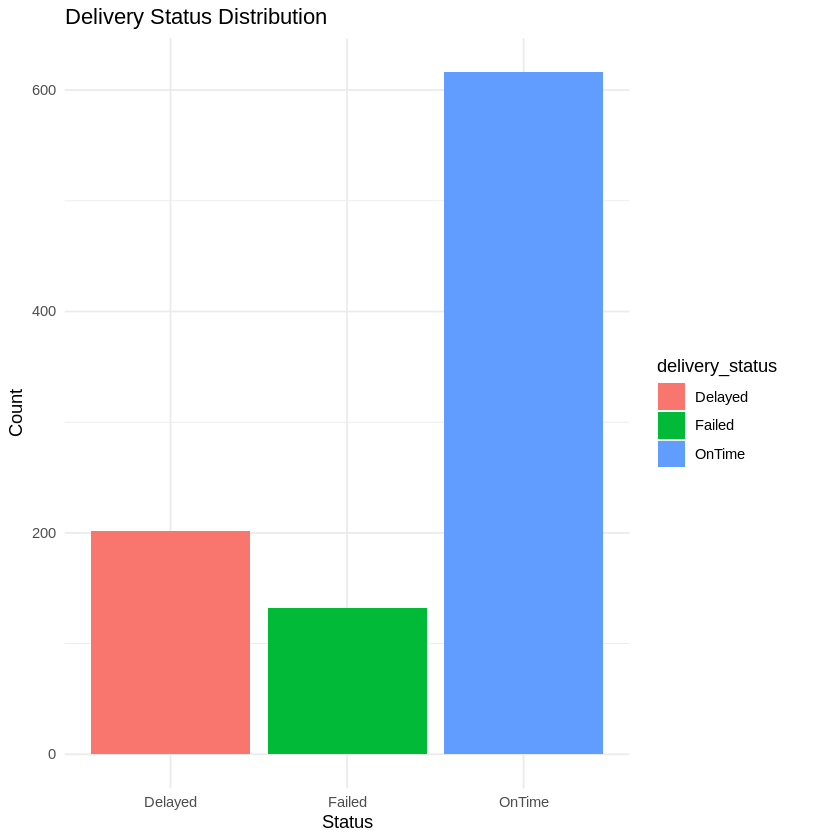

In [3]:
#3 Delivery Performance Distribution
delivery_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(count = n())

ggplot(delivery_summary, aes(x = delivery_status, y = count, fill = delivery_status)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "Delivery Status Distribution", x = "Status", y = "Count")

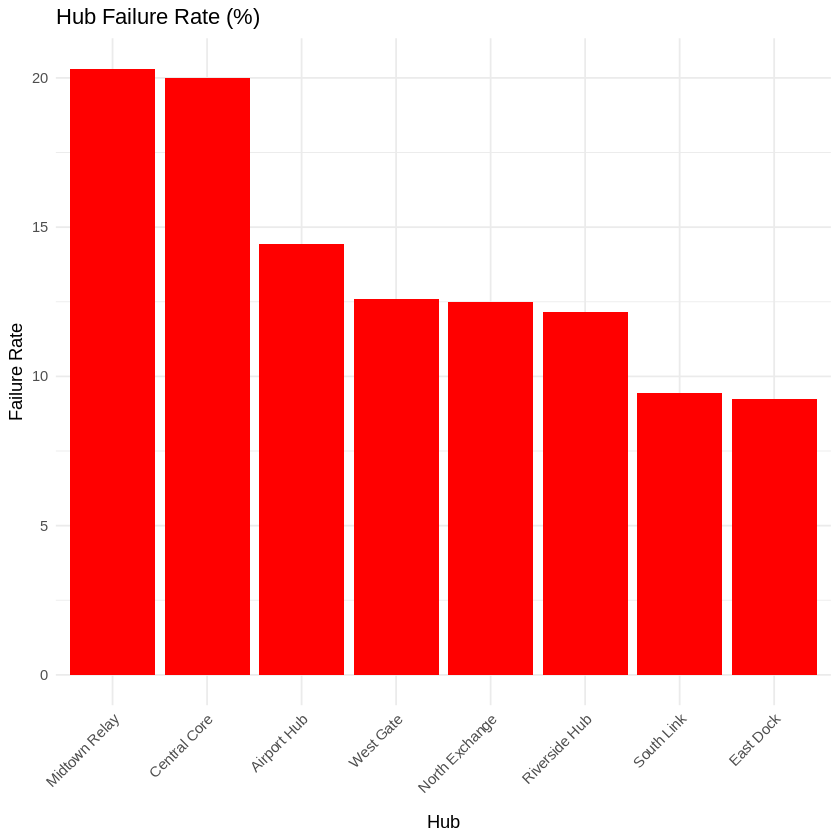

In [4]:
#4 Hub Failure Rate
hub_data <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  group_by(hub_name) %>%
  summarise(
    total = n(),
    failed = sum(delivery_status == "Failed")
  ) %>%
  mutate(failure_rate = (failed / total) * 100)

ggplot(hub_data, aes(x = reorder(hub_name, -failure_rate), y = failure_rate)) +
  geom_bar(stat = "identity", fill = "red") +
  theme_minimal() +
  labs(title = "Hub Failure Rate (%)", x = "Hub", y = "Failure Rate") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

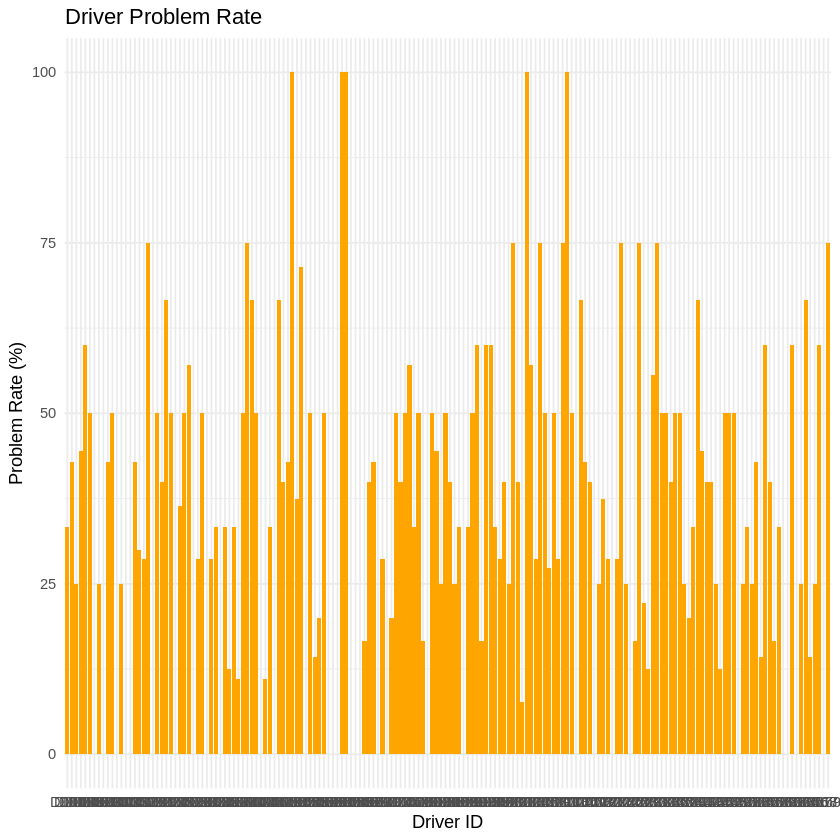

In [5]:
#5 Driver Performance Risk
driver_data <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  group_by(driver_id) %>%
  summarise(
    total = n(),
    problems = sum(delivery_status != "OnTime")
  ) %>%
  mutate(problem_rate = (problems / total) * 100)

ggplot(driver_data, aes(x = driver_id, y = problem_rate)) +
  geom_bar(stat = "identity", fill = "orange") +
  theme_minimal() +
  labs(title = "Driver Problem Rate", x = "Driver ID", y = "Problem Rate (%)")

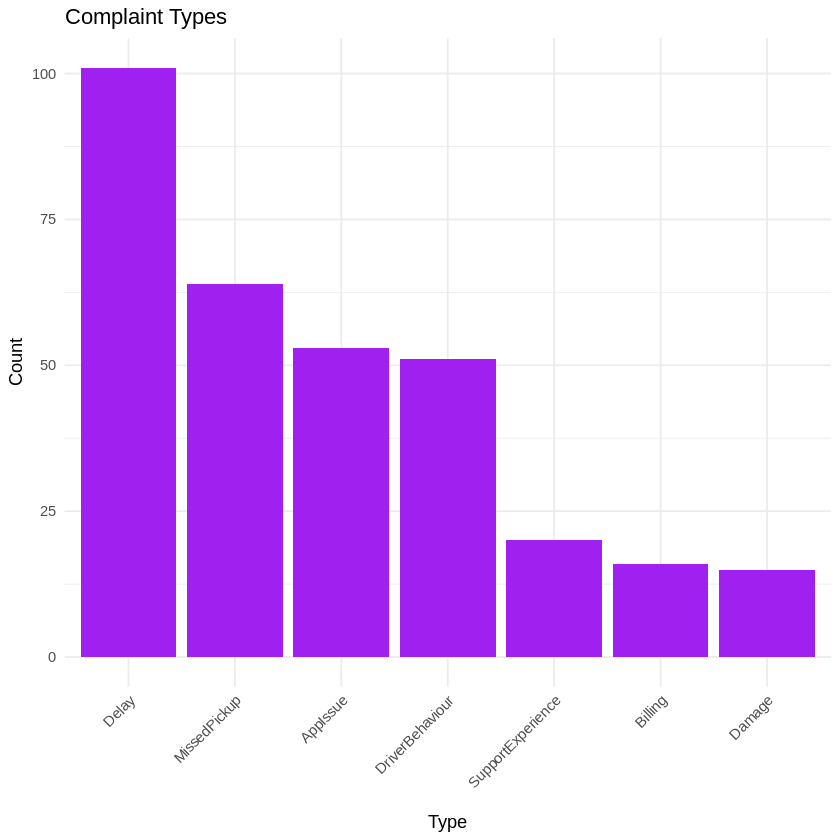

In [6]:
#6 Complaint Type Distribution
complaint_summary <- complaints %>%
  group_by(complaint_type) %>%
  summarise(count = n())

ggplot(complaint_summary, aes(x = reorder(complaint_type, -count), y = count)) +
  geom_bar(stat = "identity", fill = "purple") +
  theme_minimal() +
  labs(title = "Complaint Types", x = "Type", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

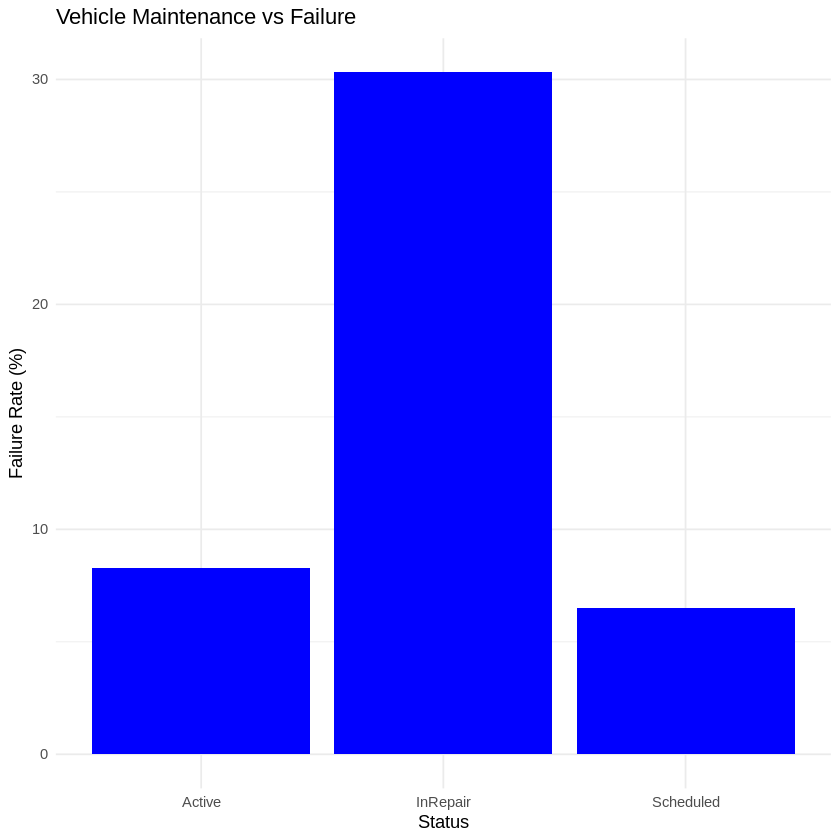

In [7]:
#7 Vehicle Maintenance vs Failure
vehicle_data <- deliveries %>%
  left_join(vehicles, by = "vehicle_id") %>%
  group_by(maintenance_status) %>%
  summarise(
    total = n(),
    failed = sum(delivery_status == "Failed")
  ) %>%
  mutate(failure_rate = (failed / total) * 100)

ggplot(vehicle_data, aes(x = maintenance_status, y = failure_rate)) +
  geom_bar(stat = "identity", fill = "blue") +
  theme_minimal() +
  labs(title = "Vehicle Maintenance vs Failure", x = "Status", y = "Failure Rate (%)")

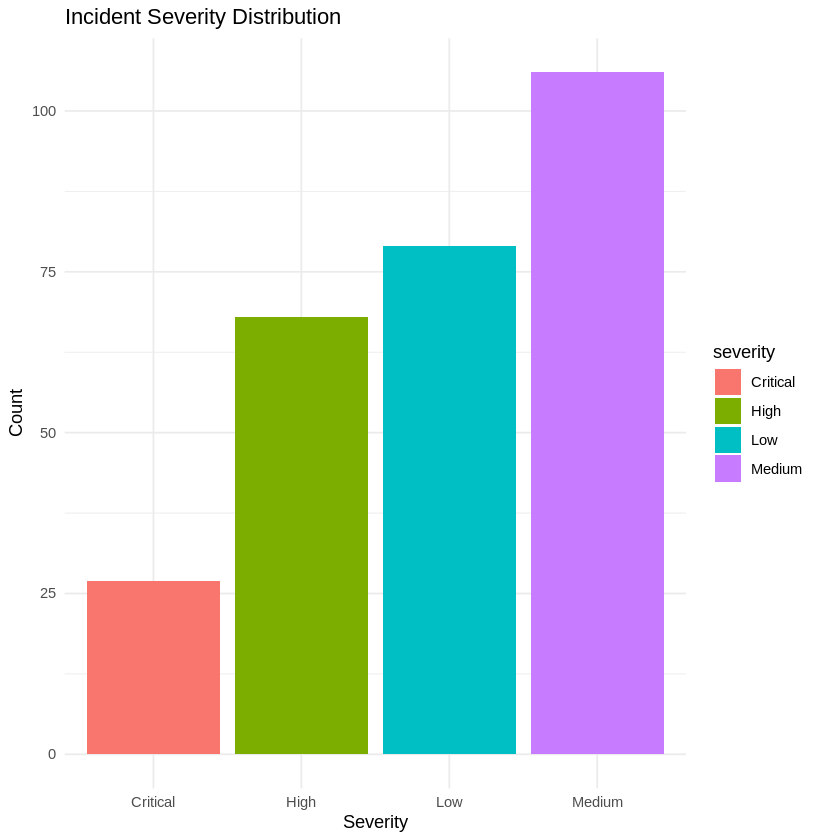

In [8]:
#8 Incident Severity Analysis
incident_summary <- incidents %>%
  group_by(severity) %>%
  summarise(count = n())

ggplot(incident_summary, aes(x = severity, y = count, fill = severity)) +
  geom_bar(stat = "identity") +
  theme_minimal() +
  labs(title = "Incident Severity Distribution", x = "Severity", y = "Count")